In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f'Generate a detailed outline for blog on this topic -{title}'
    outline = model.invoke(prompt).content

    state['outline'] = outline
    return state

In [12]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on title - {title} using the following outline\n {outline}'
    content = model.invoke(prompt).content

    state['content'] = content
    return state

In [13]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

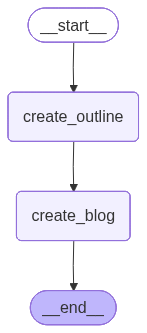

In [14]:
workflow

In [15]:
intial_state = {'title': "raise of Ai in india"}
final_state = workflow.invoke(intial_state)
print(final_state)

{'title': 'raise of Ai in india', 'outline': 'Here\'s a detailed outline for a blog on the rise of AI in India:\n\n**Title:** "The Rise of AI in India: Opportunities, Challenges, and Future Prospects"\n\n**Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Introduction to the Indian context: why AI is becoming a key focus area for the country\n* Thesis statement: India is poised to become a significant player in the global AI landscape, with opportunities and challenges that will shape the country\'s future\n\n**I. Current State of AI in India**\n\n* Overview of the current AI ecosystem in India: startups, research institutions, and industry players\n* Key statistics:\n\t+ Number of AI startups in India\n\t+ Funding received by AI startups\n\t+ AI-related research papers published by Indian institutions\n* Examples of successful AI implementations in India: e.g., chatbots, virtual assistants, image recognition systems\n\n**II. Driv

In [16]:
print(final_state['outline'])

Here's a detailed outline for a blog on the rise of AI in India:

**Title:** "The Rise of AI in India: Opportunities, Challenges, and Future Prospects"

**Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance globally
* Introduction to the Indian context: why AI is becoming a key focus area for the country
* Thesis statement: India is poised to become a significant player in the global AI landscape, with opportunities and challenges that will shape the country's future

**I. Current State of AI in India**

* Overview of the current AI ecosystem in India: startups, research institutions, and industry players
* Key statistics:
	+ Number of AI startups in India
	+ Funding received by AI startups
	+ AI-related research papers published by Indian institutions
* Examples of successful AI implementations in India: e.g., chatbots, virtual assistants, image recognition systems

**II. Drivers of AI Growth in India**

* **Government Initiatives**:
	+ National

In [17]:
print(final_state['content'])

**The Rise of AI in India: Opportunities, Challenges, and Future Prospects**

Artificial Intelligence (AI) has been gaining momentum globally, transforming industries and revolutionizing the way we live and work. India, with its vast talent pool, growing economy, and increasing adoption of technology, is poised to become a significant player in the global AI landscape. In this blog, we will explore the current state of AI in India, the drivers of AI growth, opportunities and applications, challenges and limitations, and future prospects.

**Introduction to the Indian Context**

India has been witnessing a significant surge in AI adoption, driven by government initiatives, demographic advantages, and economic factors. The country's large youth population, with a strong foundation in mathematics and science, provides a solid base for AI development. The growing middle class, with increasing access to technology, is driving demand for digital services, creating opportunities for AI implem